In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import mannwhitneyu as mwu
import ezodf

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from decimal import Decimal
from statannot import add_stat_annotation as asa
from tqdm import tqdm 
import io
from Bio.SeqUtils import molecular_weight as calculate_molecular_weight


from scipy.stats import normaltest
from scipy.stats import pearsonr

import sys
sys.path.insert(1, '../../scripts/') # comment out in python script
from utils.load_environmental_variables import *

load environmental variables
The project root is: /Users/joycebaghdassarian/Documents/UCSD/Lewis_Lab/Projects/human_me/


In [3]:
# parse and compile brenda
enzymes = open(local_data_path + 'raw/brenda_download.txt').read().split(sep = 'RECOMMENDED_NAME')[2:]
enzymes = [e for e in tqdm(enzymes) if 'Homo sapiens' in e and 'TURNOVER_NUMBER' in e]

brenda = pd.DataFrame(columns = ['EC-class', 'Protein Number', 'Turnover (s^-1)'])

error_lines = ['pH', 'hydrolysis', 'comparison', 'F152I,']
brenda_idx = 0
counter = 0
for e in enzymes:
    id_ = e[e.index('ID\t'):].split('\t')[1].split('\n')[0]
    if 'PROTEIN' in e:
        e = e.split('\n\n')
        turnover = [i for i in e if 'TURNOVER_NUMBER' in i][0].split('\n')[1:] # get kcats
        protein = [i for i in e if 'PROTEIN' in i][0].split('\n')
        protein = [i.split('\t')[1].split(' Homo sapiens')[0] for i in protein if 'Homo sapiens' in i] # get protein no for human

        # filter for turnover numbers of human proteins
        turnover = [i for i in turnover if i.split('\t')[1].split(' ')[0] in protein]
        if len(turnover)>0:
            for i in turnover:
                comment = i.split('(')
                if len(comment)==1 or 'mutant' not in comment[1]: # filter out mutant proteins
                    vals = i.split('\t')[1].split(' ')
                    protein_no = vals[0]
                    if protein_no in protein:
                        if vals[1] not in error_lines and '-' not in vals[1]:
                            turnover_ = float(vals[1])
                        else: 
                            if '-' in vals[1]: 
                                if len(vals[1].split('-')) > 2:
                                    turnover_ = np.mean([float(i) for i in vals[1].split('-')]) # take avg when a range is provided
                                else:
                                    pass # only one end of range provided
                            elif vals[1] in error_lines:
                                pass # disregard the weird parsed line
                        brenda.loc[brenda_idx, :] = [id_, protein_no, turnover_]
                        brenda_idx += 1
    
brenda['Turnover (s^-1)'] = brenda['Turnover (s^-1)'].astype(float)

# take average across unique EC-class - Protein No pairs
brenda = pd.DataFrame(brenda.groupby(['EC-class', 'Protein Number'])['Turnover (s^-1)'].mean())
brenda.to_csv(local_data_path + 'processed/brenda_keff.csv')

100%|██████████| 7557/7557 [00:00<00:00, 55290.54it/s]


In [729]:
turn_char = 'Turnover (s^-1)'
k_eff_median = brenda[turn_char].median()
print(k_eff_median)

3.983333333333333


/Users/joycebaghdassarian/opt/anaconda3/envs/human_me/lib/python3.6/site-packages/seaborn/distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


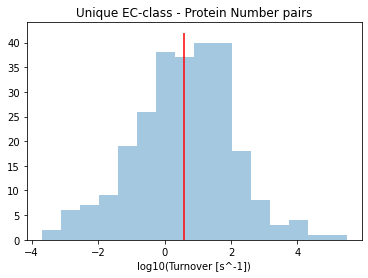

In [692]:
fig, ax = plt.subplots()
sns.distplot(np.log10(brenda[turn_char]), kde = False, ax = ax)
ax.set(xlabel = 'log10(Turnover [s^-1])', title = 'Unique EC-class - Protein Number pairs')
ylim = ax.get_ylim()
ax.vlines(np.log10(np.log10(k_eff_median)), ymin = ylim[0], ymax = ylim[1], color = 'red')
plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution.png')
plt.savefig(local_data_path + 'figures/enzyme_turnover_distribution.pdf')

In [694]:
psim_me = pd.read_csv(local_data_path + 'processed/corrected_psim_me.csv', index_col = 0) #psim_me = pd.read_csv(root_path+'TRASH.csv', index_col = 0)

def cmw(x):
    try:
        mw = calculate_molecular_weight(x, seq_type = 'protein')
    except:
        mw = float('nan')
    return mw


mw_list = psim_me.PROTEIN_SEQ.apply(lambda x: cmw(x))
mw_list.dropna(inplace = True)
psim_me = psim_me.loc[mw_list.index, :]

def SASA(protein_seq):
    mw = calculate_molecular_weight(protein_seq, seq_type = 'protein')
    return mw**(0.75)
    
    
def est_keff(protein_seq, mw_list = mw_list, k_eff_median = k_eff_median):
    try:
        keff = SASA(protein_seq)*(k_eff_median/np.median(mw_list))
    except:
        keff = float('nan')
    return keff